In [554]:
# Imports ----------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp

sns.set_theme(style="whitegrid")

In [555]:
# Load Real Electricity Demand Data -----------------------

df = pd.read_csv("data/AEP_hourly.csv")
df.head()
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.sort_values("Datetime")

df = df.rename(columns={"AEP_MW": "Demand"})
df = df.reset_index(drop=True)

df = df.iloc[:24*7].copy()

In [556]:
# Simulated Price Data --------------------------------------------------

hours = np.arange(len(df))

price = 30 + 40 * np.where((hours % 24 >= 14) & (hours % 24 <= 20), 1, 0)
price = price + np.random.normal(0, 3, len(df))

df["Price"] = np.clip(price, 5, None)

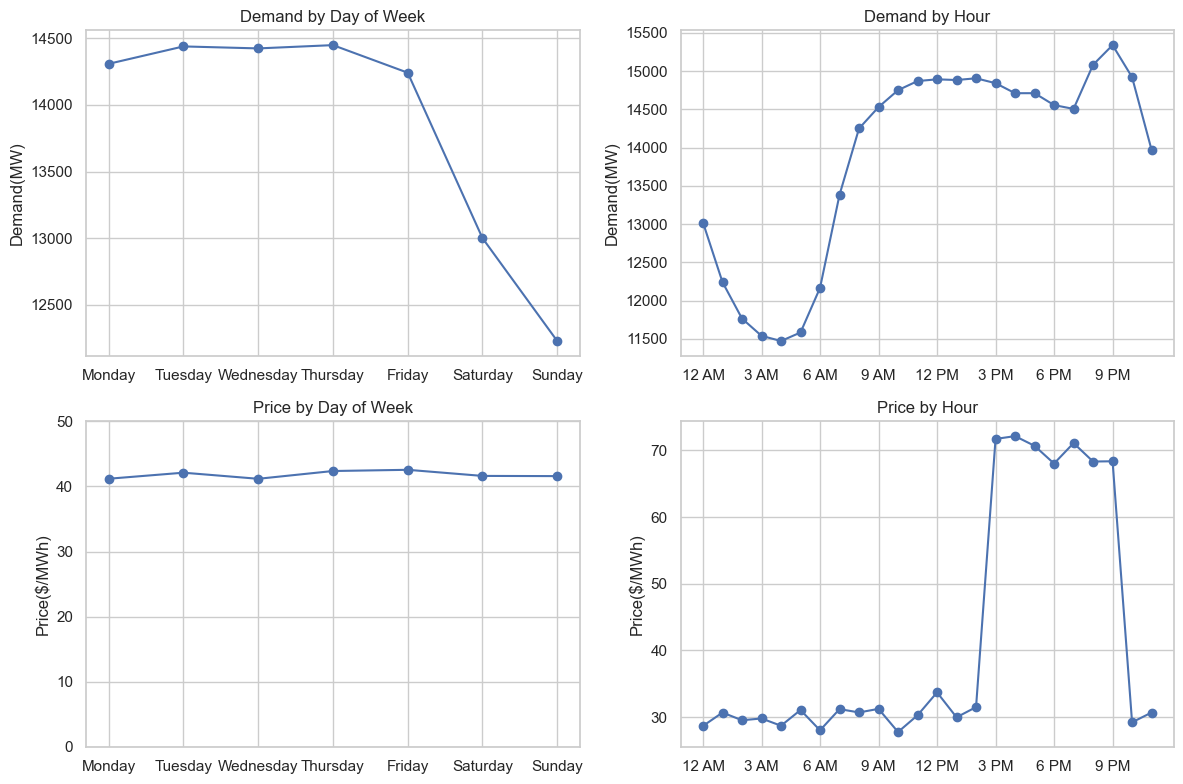

In [557]:
df["Datetime"] = pd.to_datetime(df["Datetime"])
df = df.set_index("Datetime")

df["Day"] = df.index.day_name()
df["Hour"] = df.index.hour

day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

import matplotlib.pyplot as plt

# --- Aggregate data ---
# Ensure correct day order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Group by day of week
demand_day = df.groupby("Day")["Demand"].mean().reindex(day_order)
price_day = df.groupby("Day")["Price"].mean().reindex(day_order)

# Group by hour
demand_hour = df.groupby("Hour")["Demand"].mean()
price_hour = df.groupby("Hour")["Price"].mean()

# --- Plot ---
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# Demand by Day
axs[0, 0].plot(demand_day.index, demand_day.values, marker='o')
axs[0, 0].set_title("Demand by Day of Week")
axs[0, 0].set_ylabel("Demand(MW)")

# Demand by Hour
axs[0, 1].plot(demand_hour.index, demand_hour.values, marker='o')
axs[0, 1].set_title("Demand by Hour")
axs[0, 1].set_xticks([0, 3, 6, 9, 12, 15, 18, 21])
axs[0, 1].set_xticklabels(["12 AM", "3 AM", "6 AM", "9 AM",
                          "12 PM", "3 PM", "6 PM", "9 PM"])
axs[0, 1].set_ylabel("Demand(MW)")

# Price by Day
axs[1, 0].plot(demand_day.index, price_day.values, marker='o')
axs[1, 0].set_title("Price by Day of Week")
axs[1, 0].set_ylabel("Price($/MWh)")
axs[1, 0].set_yticks([0, 10, 20, 30, 40, 50])

# Price by Hour
axs[1, 1].plot(price_hour.index, price_hour.values, marker='o')
axs[1, 1].set_title("Price by Hour")
axs[1, 1].set_xticks([0, 3, 6, 9, 12, 15, 18, 21])
axs[1, 1].set_xticklabels(["12 AM", "3 AM", "6 AM", "9 AM",
                          "12 PM", "3 PM", "6 PM", "9 PM"])
axs[1, 1].set_ylabel("Price($/MWh)")

plt.tight_layout()
plt.show()

In [558]:
import cvxpy as cp
import numpy as np

# Data
T = len(df)

demand = df["Demand"].values
price = df["Price"].values

# Decision variables ----------
charge = cp.Variable(T)
discharge = cp.Variable(T)
battery = cp.Variable(T)
grid = cp.Variable(T)
peak = cp.Variable()

# System parameters ------------------------
capacity = 50000
charge_max = 5000
discharge_max = 5000

grid_capacity = np.percentile(demand, 90)

efficiency = 0.9  # realistic battery efficiency

# Scaling penalties --------------------------------
price_scale = np.mean(price)

peak_penalty = 0.002 * price_scale
ramp_penalty = 0.0014 * price_scale
cycle_penalty = 0.0005 * price_scale  # discourages unnecessary cycling


# Objective ------------------------------------------------
objective = cp.Minimize(
    cp.sum(cp.multiply(price, grid)) +
    peak_penalty * peak +
    ramp_penalty * cp.sum_squares(grid[1:] - grid[:-1]) +
    cycle_penalty * cp.sum(charge + discharge)
)

# Constraints --------------------------------------------------
constraints = []

for t in range(T):

    # Energy balance (with efficiency)
    constraints += [
        grid[t] + discharge[t] == demand[t] + charge[t] / efficiency,

        # bounds
        charge[t] >= 0,
        discharge[t] >= 0,
        grid[t] >= 0,

        charge[t] <= charge_max,
        discharge[t] <= discharge_max,

        battery[t] >= 0,
        battery[t] <= capacity,

        grid[t] <= grid_capacity
    ]

    # Battery dynamics
    if t == 0:
        constraints += [
            battery[t] == charge[t] * efficiency - discharge[t],
            battery[t] == 0  # initial condition
        ]
    else:
        constraints += [
            battery[t] == battery[t-1] + charge[t] * efficiency - discharge[t]
        ]

# Peak definition
constraints += [grid <= peak]

# End condition (avoid leftover energy)
constraints += [battery[T-1] == 0]

# Ramp constraint (not overly restrictive)
ramp_limit = 6000
for t in range(1, T):
    constraints += [
        cp.abs(grid[t] - grid[t-1]) <= ramp_limit
    ]

# Solve ---------------------------------------
problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.SCS)

np.float64(96782173.00850083)

In [559]:
# Baseline Comparison --------------------------------

baseline_cost = np.sum(price * demand)
optimized_cost = problem.value

print("Baseline cost:", baseline_cost)
print("Optimized cost:", optimized_cost)
print("Savings:", baseline_cost - optimized_cost)

# Peak Shaving ------------------------------------

peak_original = np.max(demand)
peak_new = np.max(grid.value)

print("Peak demand:", peak_original)
print("Peak grid usage:", peak_new)
print("Reduction:", peak_original - peak_new)

# Load Smoothing ----------------------------------

variability_original = np.std(demand)
variability_new = np.std(grid.value)

print("Original variability:", variability_original)
print("New variability:", variability_new)


Baseline cost: 99329913.59024394
Optimized cost: 96782173.00850083
Savings: 2547740.5817431062
Peak demand: 16133.0
Peak grid usage: 15618.261873487045
Reduction: 514.7381265129552
Original variability: 1598.0629201953673
New variability: 1471.53398157624


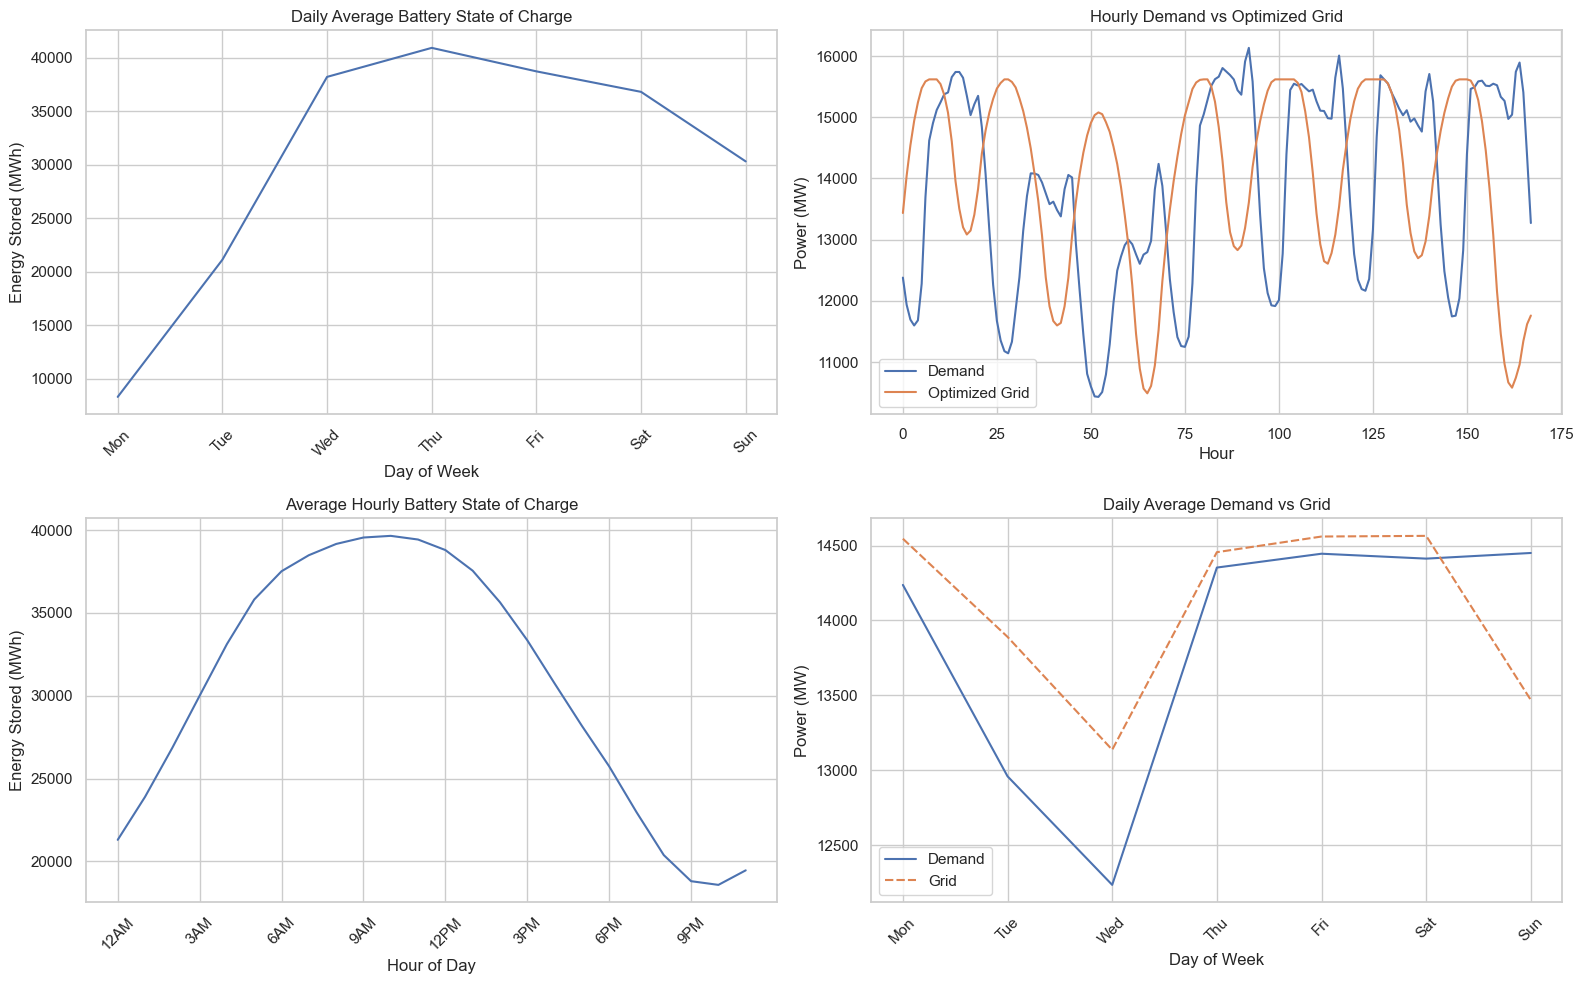

In [560]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Build plotting dataframe ----------------------------

plot_df = pd.DataFrame({
    "Hour": np.arange(T),
    "Demand": demand,                 # MW
    "Grid": grid.value,               # MW
    "Battery": battery.value          # MWh (state of charge)
})

# Hour of day (0–23)
plot_df["HourOfDay"] = plot_df["Hour"] % 24

# Day index (assuming 24-hour blocks)
plot_df["DayIndex"] = plot_df["Hour"] // 24

day_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]



# Create figure -----------------------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# (1) TOP LEFT — Daily Battery State of Charge ---------------------------

daily_battery = plot_df.groupby("DayIndex")["Battery"].mean()

sns.lineplot(x=np.arange(len(daily_battery)), y=daily_battery.values, ax=axes[0,0])

axes[0,0].set_title("Daily Average Battery State of Charge")
axes[0,0].set_xlabel("Day of Week")
axes[0,0].set_ylabel("Energy Stored (MWh)")

axes[0,0].set_xticks(np.arange(len(daily_battery)))
axes[0,0].set_xticklabels(day_labels[:len(daily_battery)], rotation=45)


# (2) TOP RIGHT — Demand vs Grid -------------------------------------

sns.lineplot(data=plot_df, x="Hour", y="Demand", ax=axes[0,1], label="Demand")
sns.lineplot(data=plot_df, x="Hour", y="Grid", ax=axes[0,1], label="Optimized Grid")

axes[0,1].set_title("Hourly Demand vs Optimized Grid")
axes[0,1].set_xlabel("Hour")
axes[0,1].set_ylabel("Power (MW)")


# (3) BOTTOM LEFT — Average Hourly Battery SOC -----------------

hourly_battery = plot_df.groupby("HourOfDay")["Battery"].mean()

sns.lineplot(x=hourly_battery.index, y=hourly_battery.values, ax=axes[1,0])

axes[1,0].set_title("Average Hourly Battery State of Charge")
axes[1,0].set_xlabel("Hour of Day")
axes[1,0].set_ylabel("Energy Stored (MWh)")

axes[1,0].set_xticks(np.arange(0, 24, 3))
axes[1,0].set_xticklabels(
    ["12AM","3AM","6AM","9AM","12PM","3PM","6PM","9PM"],
    rotation=45
)


# (4) BOTTOM RIGHT — Daily pattern Demand vs Grid --------------

daily = pd.DataFrame({
    "Demand": np.array(demand).reshape(-1, 24).mean(axis=1),
    "Grid": np.array(grid.value).reshape(-1, 24).mean(axis=1)
})

sns.lineplot(data=daily, ax=axes[1,1])

axes[1,1].set_title("Daily Average Demand vs Grid")
axes[1,1].set_xlabel("Day of Week")
axes[1,1].set_ylabel("Power (MW)")

axes[1,1].set_xticks(np.arange(len(daily)))
axes[1,1].set_xticklabels(day_labels[:len(daily)], rotation=45)


# Final layout

plt.tight_layout()
plt.show()

In [561]:
# Optimization Function ---------------------------------------------

def run_optimization(capacity):

    # Data
    T = len(df)

    demand = df["Demand"].values
    price = df["Price"].values

    # Decision variables ----------
    charge = cp.Variable(T)
    discharge = cp.Variable(T)
    battery = cp.Variable(T)
    grid = cp.Variable(T)
    peak = cp.Variable()

    # System parameters ------------------------
    charge_max = 5000
    discharge_max = 5000

    grid_capacity = np.percentile(demand, 90)

    efficiency = 0.9  # realistic battery efficiency

    # Scaling penalties --------------------------------
    price_scale = np.mean(price)

    peak_penalty = 0.002 * price_scale
    ramp_penalty = 0.0014 * price_scale
    cycle_penalty = 0.0005 * price_scale  # discourages unnecessary cycling


    # Objective ------------------------------------------------
    objective = cp.Minimize(
    cp.sum(cp.multiply(price, grid)) +
    peak_penalty * peak +
    ramp_penalty * cp.sum_squares(grid[1:] - grid[:-1]) +
    cycle_penalty * cp.sum(charge + discharge))

    # Constraints --------------------------------------------------
    constraints = []

    for t in range(T):

        # Energy balance (with efficiency)
        constraints += [
            grid[t] + discharge[t] == demand[t] + charge[t] / efficiency,

        # bounds
        charge[t] >= 0,
        discharge[t] >= 0,
        grid[t] >= 0,

        charge[t] <= charge_max,
        discharge[t] <= discharge_max,

        battery[t] >= 0,
        battery[t] <= capacity,

        grid[t] <= grid_capacity
    ]

    # Battery dynamics
        if t == 0:
            constraints += [
                battery[t] == charge[t] * efficiency - discharge[t],
                battery[t] == 0  # initial condition
            ]
        else:
            constraints += [
                battery[t] == battery[t-1] + charge[t] * efficiency - discharge[t]
            ]

    # Peak definition
    constraints += [grid <= peak]

    # End condition (avoid leftover energy)
    constraints += [battery[T-1] == 0]

    # Ramp constraint (not overly restrictive)
    ramp_limit = 6000
    for t in range(1, T):
        constraints += [
            cp.abs(grid[t] - grid[t-1]) <= ramp_limit
        ]

    # Solve ---------------------------------------
    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.SCS)
    variability = np.std(grid.value)
    cost = problem.value
    peak = np.max(grid.value)

    return cost, peak, variability

baseline_cost = np.sum(price * demand)
baseline_peak = np.max(demand)
baseline_variability = np.std(demand)

results = []

# No Battery ----------------------------------------------
results.append({
    "Case": "No Battery",
    "Cost": baseline_cost,
    "Peak": baseline_peak,
    "Variability": baseline_variability
})

# Small Battery --------------------------------------------
cost, peak, var = run_optimization(capacity=10000)
results.append({
    "Case": "Small Battery",
    "Cost": cost,
    "Peak": peak,
    "Variability": var
})

# Medium Battery --------------------------------------------
cost, peak, var = run_optimization(capacity=20000)
results.append({
    "Case": "Medium Battery",
    "Cost": cost,
    "Peak": peak,
    "Variability": var
})

# Large Battery --------------------------------------------
cost, peak, var = run_optimization(capacity=40000)
results.append({
    "Case": "Large Battery",
    "Cost": cost,
    "Peak": peak,
    "Variability": var
})

results_df = pd.DataFrame(results)
results_df

C:\Users\karth\AppData\Local\Temp\ipykernel_4488\326622843.py:90: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.SCS)


,Case,Cost,Peak,Variability
0,No Battery,9.932991e+07,16133.000000,1598.062920
1,Small Battery,9.795572e+07,15643.559289,1030.049351
2,Medium Battery,9.694273e+07,15618.213604,1357.393532
3,Large Battery,9.680645e+07,15618.285334,1463.335424


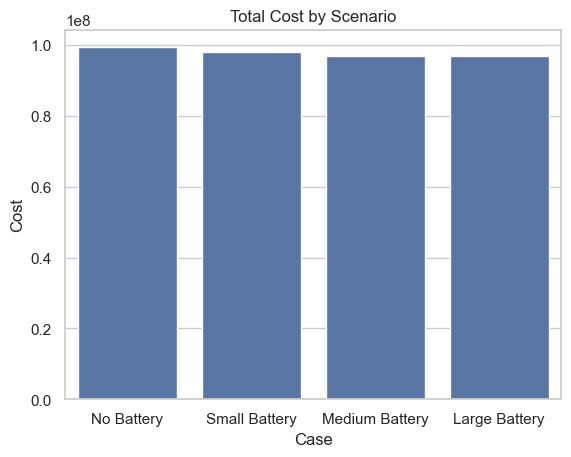

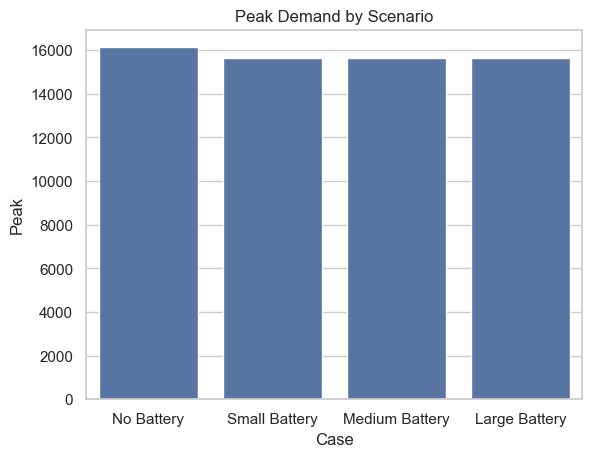

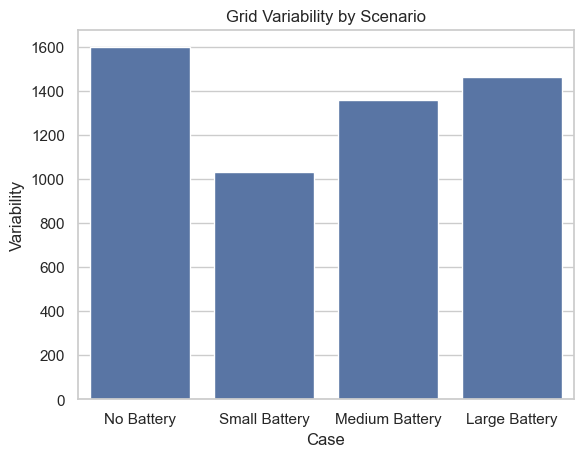

In [562]:
# Cost Comparison --------------------------------------------------

sns.barplot(data=results_df, x="Case", y="Cost")
plt.title("Total Cost by Scenario")
plt.show()

# Peak Comparsion ----------------------------------------------

sns.barplot(data=results_df, x="Case", y="Peak")
plt.title("Peak Demand by Scenario")
plt.show()

# Variability Comparison --------------------------------------------

sns.barplot(data=results_df, x="Case", y="Variability")
plt.title("Grid Variability by Scenario")
plt.show()

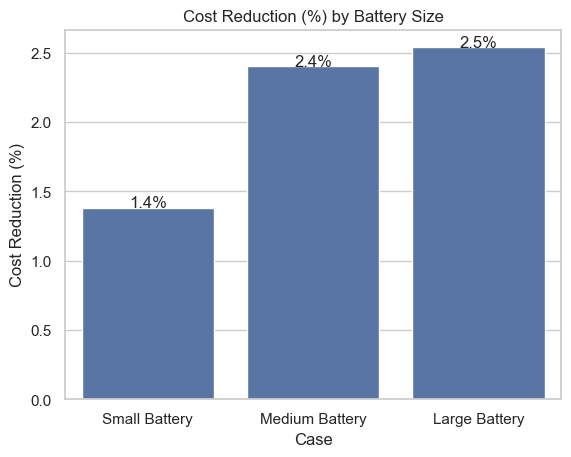

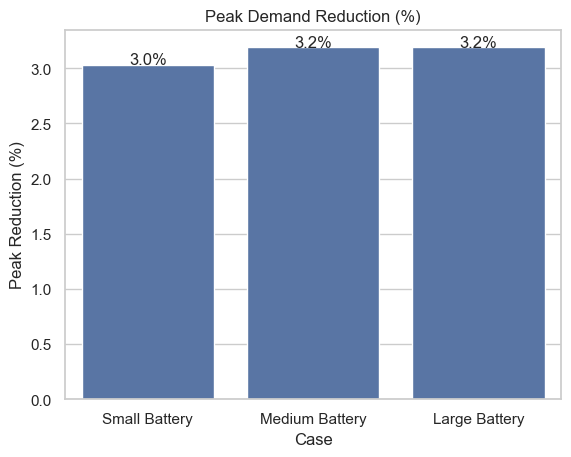

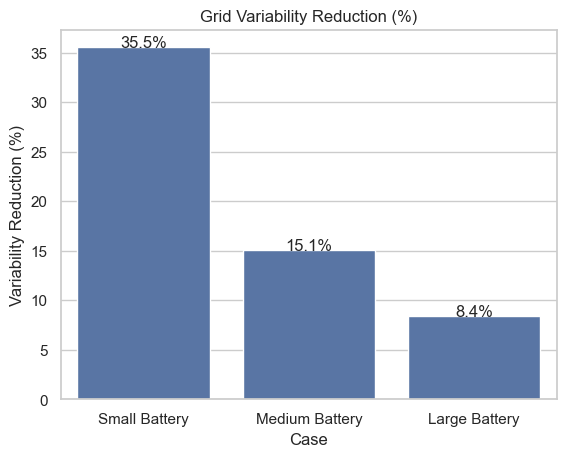

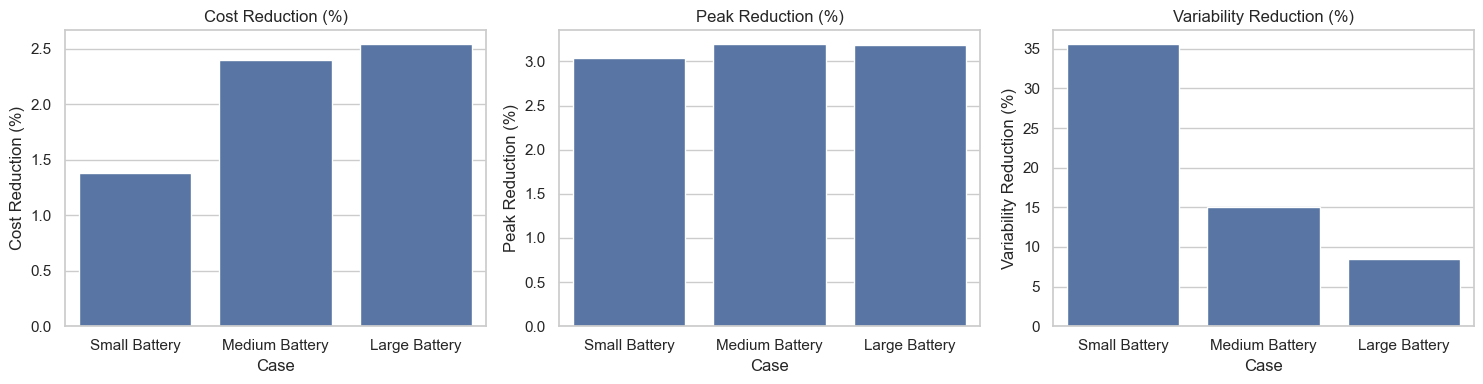

In [563]:
# Percentage Improvements --------------------------------------

results_df["Cost Reduction (%)"] = (
    (baseline_cost - results_df["Cost"]) / baseline_cost * 100
)

results_df["Peak Reduction (%)"] = (
    (baseline_peak - results_df["Peak"]) / baseline_peak * 100
)

results_df["Variability Reduction (%)"] = (
    (baseline_variability - results_df["Variability"]) / baseline_variability * 100
)

results_df
plot_df = results_df[results_df["Case"] != "No Battery"].reset_index(drop=True)

# Plot 1 -------------------------------------------------------------

plt.figure()
ax = sns.barplot(data=plot_df, x="Case", y="Cost Reduction (%)")

for i, row in plot_df.iterrows():
    ax.text(i, row["Cost Reduction (%)"], f"{row['Cost Reduction (%)']:.1f}%", ha='center')

plt.title("Cost Reduction (%) by Battery Size")
plt.show()

# Plot 2 ----------------------------------------------------------------

plt.figure()
ax = sns.barplot(data=plot_df, x="Case", y="Peak Reduction (%)")

for i, row in plot_df.iterrows():
    ax.text(i, row["Peak Reduction (%)"], f"{row['Peak Reduction (%)']:.1f}%", ha='center')

plt.title("Peak Demand Reduction (%)")
plt.show()

# Plot 3 ----------------------------------------------------------------------------------

plt.figure()
ax = sns.barplot(data=plot_df, x="Case", y="Variability Reduction (%)")

for i, row in plot_df.iterrows():
    ax.text(i, row["Variability Reduction (%)"], f"{row['Variability Reduction (%)']:.1f}%", ha='center')

plt.title("Grid Variability Reduction (%)")
plt.show()

# Combined Figure --------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Cost Reduction
sns.barplot(data=plot_df, x="Case", y="Cost Reduction (%)", ax=axes[0])
axes[0].set_title("Cost Reduction (%)")

# Peak Reduction
sns.barplot(data=plot_df, x="Case", y="Peak Reduction (%)", ax=axes[1])
axes[1].set_title("Peak Reduction (%)")

# Variability Reduction (if exists)
sns.barplot(data=plot_df, x="Case", y="Variability Reduction (%)", ax=axes[2])
axes[2].set_title("Variability Reduction (%)")

plt.tight_layout()
plt.show()

## Results Interpretation

The results show that adding battery storage reduces total electricity cost and peak demand, with the largest improvements occurring at smaller storage capacities. Moving from no battery to a small battery yields significant cost savings and a substantial reduction in peak grid usage, highlighting the strong initial value of storage.

As battery capacity increases, the system continues to benefit, but with clear diminishing returns. The transition from small to medium storage provides moderate additional savings, while further increases to large capacity result in only marginal improvements. This indicates that beyond a certain point, system performance is limited more by operational constraints—such as charge and discharge rates—than by total storage capacity.

In terms of system behavior, battery storage initially reduces variability by smoothing demand and shifting energy away from peak periods. However, at higher capacities, variability can increase slightly due to more aggressive charge and discharge patterns. This highlights an important trade-off: while storage improves economic performance and peak reduction, larger capacities do not necessarily lead to smoother grid operation without explicitly optimizing for it.

Overall, the results demonstrate that storage is a highly effective tool for cost reduction and peak management, but its marginal value decreases at higher capacities and depends strongly on system constraints and objective design.

# Conclusion

This project combines data analysis, machine learning, and optimization to study electricity demand and the role of battery storage in power systems. Using real-world data from the AEP region, the analysis identifies key temporal patterns in electricity usage and demonstrates how these patterns can be leveraged for forecasting.

Building on this, the optimization model shows how battery storage can reduce costs, shift energy usage away from high-price periods, and lower peak demand. Scenario analysis across different storage capacities reveals that these benefits exhibit diminishing returns and are ultimately constrained by operational limits such as charge and discharge rates.

Importantly, the results also highlight that increasing storage capacity introduces trade-offs. While smaller batteries improve both cost and system stability, larger capacities can lead to increased variability due to more flexible but less constrained energy shifting.

Overall, this project illustrates how data-driven analysis and optimization can be combined to better understand and design energy systems, providing insight into both the benefits and limitations of battery storage in real-world grid operations.